In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("C:/Users/sarth/Desktop/echochain_analyis/EchoChain_Data_Cleaned.csv")

In [4]:
# Convert date columns
date_columns = [
    "Purchase_Date",
    "Resale_Date",
    "Recycling_Date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [5]:
# Display basic information
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (10000, 33)


,Transaction_ID,Product_ID,Product_Category,Product_Name,Brand,Purchase_Date,Original_Price_INR,Current_Market_Value_INR,Condition_at_Resale,Ownership_Cycle,...,Recycled,Recycling_Date,Material_Recovered_Kg,CO2_Saved_Kg,Waste_Diverted_Kg,Circularity_Score,Customer_Rating,Region,City,Final_Disposition
0,EC00001,PRD00001,Fashion,Denim,Levi's,2024-01-02,23860,19270,Good,2,...,Yes,2028-03-16,8.16,158.73,6.26,72.0,4.4,North,Lucknow,Recycled
1,EC00002,PRD00002,Fashion,Sneakers,Levi's,NaT,13850,11160,Like New,5,...,No,NaT,0.00,53.18,0.20,78.8,4.1,North,Delhi,Resold
2,EC00003,PRD00003,Laptops,Pavilion,Acer,2023-11-05,166800,96100,Like New,3,...,No,NaT,0.00,466.69,13.17,72.3,3.4,South,Hyderabad,Refurbished
3,EC00004,PRD00004,Laptops,ThinkPad,Apple,NaT,55480,48270,Fair,2,...,No,NaT,0.00,253.35,2.64,49.1,2.9,West,Ahmedabad,Refurbished
4,EC00005,PRD00005,Smartphones,OnePlus,OnePlus,2024-05-02,116430,58620,Like New,2,...,No,NaT,0.00,269.09,5.18,56.3,4.6,South,Chennai,Refurbished


### **Dataset Overview**

In [6]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
for col in df.columns:
    print(col)

Number of Rows: 10000
Number of Columns: 33

Column Names:
Transaction_ID
Product_ID
Product_Category
Product_Name
Brand
Purchase_Date
Original_Price_INR
Current_Market_Value_INR
Condition_at_Resale
Ownership_Cycle
Resale_Date
Resale_Price_INR
Seller_Type
Buyer_Type
Platform
Refurbished
Refurbishment_Cost_INR
Repair_Count
Product_Age_Months
Usage_Hours
Warranty_Status
Return_Status
Recycling_Eligible
Recycled
Recycling_Date
Material_Recovered_Kg
CO2_Saved_Kg
Waste_Diverted_Kg
Circularity_Score
Customer_Rating
Region
City
Final_Disposition


### **Check Missing Values**

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing %": (missing.values / len(df) * 100).round(2)
})

display(missing_df[missing_df["Missing Values"] > 0])

,Column,Missing Values,Missing %
0,Recycling_Date,8486,84.86
1,Purchase_Date,6027,60.27
2,Resale_Date,6027,60.27


### **Executive KPI calculations**

In [8]:
total_transactions = df["Transaction_ID"].nunique()

total_original_value = df["Original_Price_INR"].sum()

total_resale_revenue = df["Resale_Price_INR"].sum()

average_resale_price = df["Resale_Price_INR"].mean()

average_circularity = df["Circularity_Score"].mean()

average_customer_rating = df["Customer_Rating"].mean()

print("EXECUTIVE KPIs")
print("-" * 40)
print(f"Total Transactions       : {total_transactions:,}")
print(f"Total Original Value     : ₹{total_original_value:,.2f}")
print(f"Total Resale Revenue     : ₹{total_resale_revenue:,.2f}")
print(f"Average Resale Price     : ₹{average_resale_price:,.2f}")
print(f"Average Circularity Score: {average_circularity:.2f}")
print(f"Average Customer Rating  : {average_customer_rating:.2f}/5")

EXECUTIVE KPIs
----------------------------------------
Total Transactions       : 10,000
Total Original Value     : ₹697,009,100.00
Total Resale Revenue     : ₹283,401,820.00
Average Resale Price     : ₹28,340.18
Average Circularity Score: 60.72
Average Customer Rating  : 3.87/5


### **Resale Revenue by Product Category**

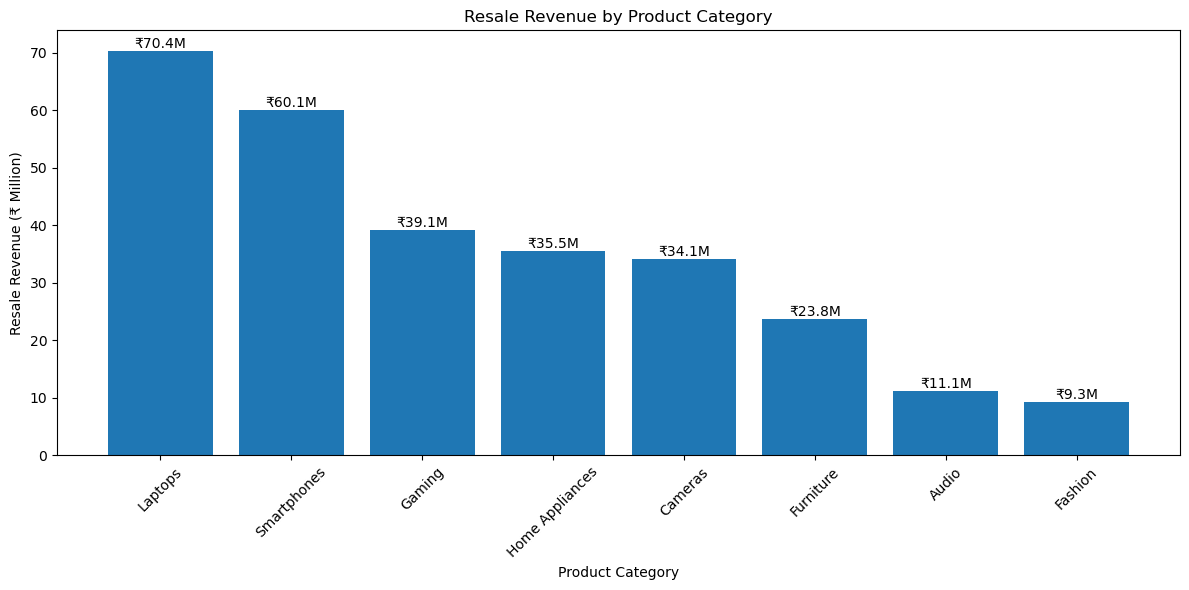

In [9]:
# for dashboard 1 chart
category_revenue = (
    df.groupby("Product_Category")["Resale_Price_INR"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    category_revenue.index,
    category_revenue.values / 1_000_000
)

plt.title("Resale Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Resale Revenue (₹ Million)")
plt.xticks(rotation=45)

for bar, value in zip(bars, category_revenue.values / 1_000_000):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"₹{value:.1f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### **Transactions by Region**

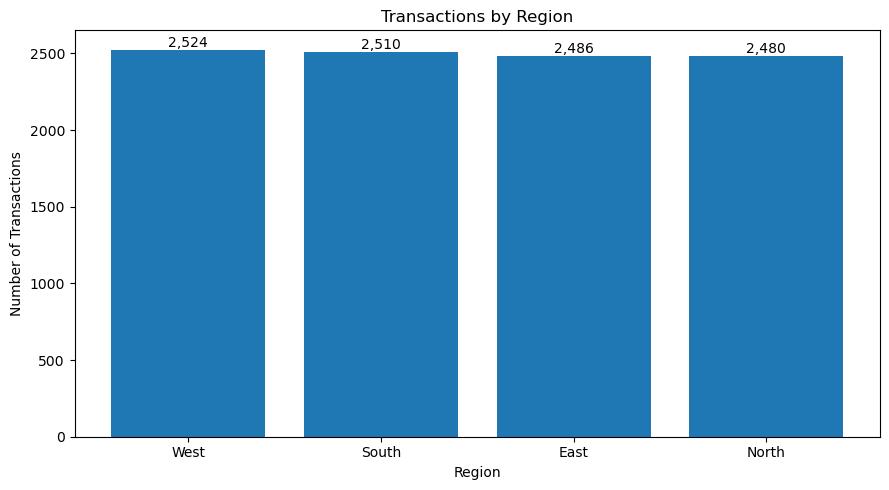

In [10]:
region_transactions = (
    df["Region"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    region_transactions.index,
    region_transactions.values
)

plt.title("Transactions by Region")
plt.xlabel("Region")
plt.ylabel("Number of Transactions")

for bar, value in zip(bars, region_transactions.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### **Transactions by Platform**

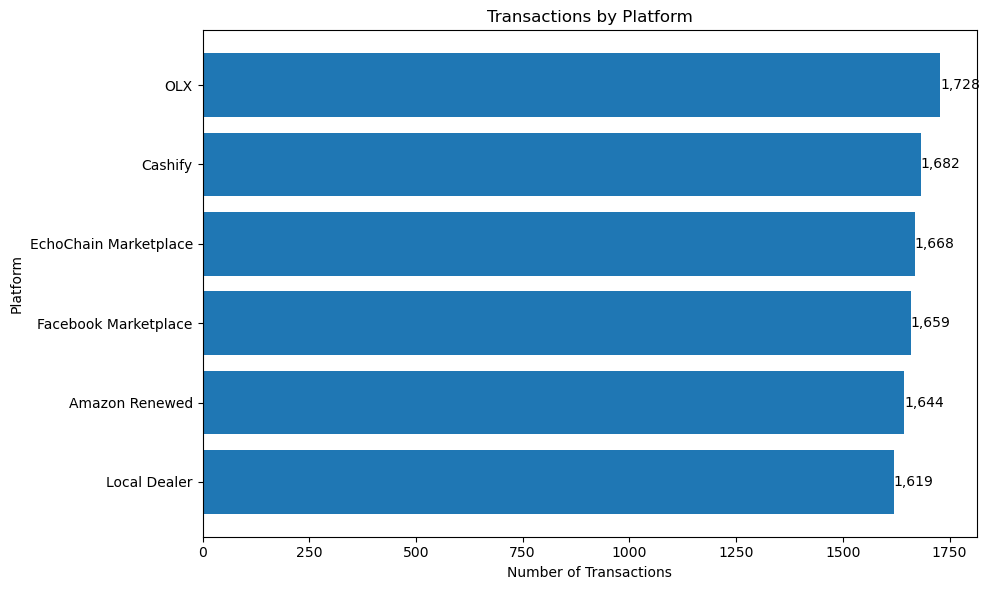

In [11]:
platform_transactions = (
    df["Platform"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    platform_transactions.index,
    platform_transactions.values
)

plt.title("Transactions by Platform")
plt.xlabel("Number of Transactions")
plt.ylabel("Platform")

for bar, value in zip(bars, platform_transactions.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

### **Final Disposition of Products**

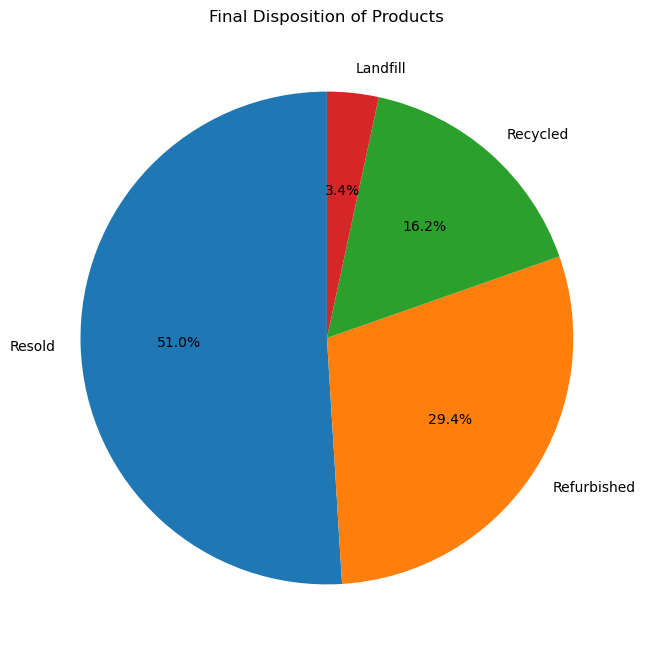

In [12]:
disposition = df["Final_Disposition"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    disposition.values,
    labels=disposition.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Final Disposition of Products")

plt.show()

### **Monthly Resale Revenue Trend**

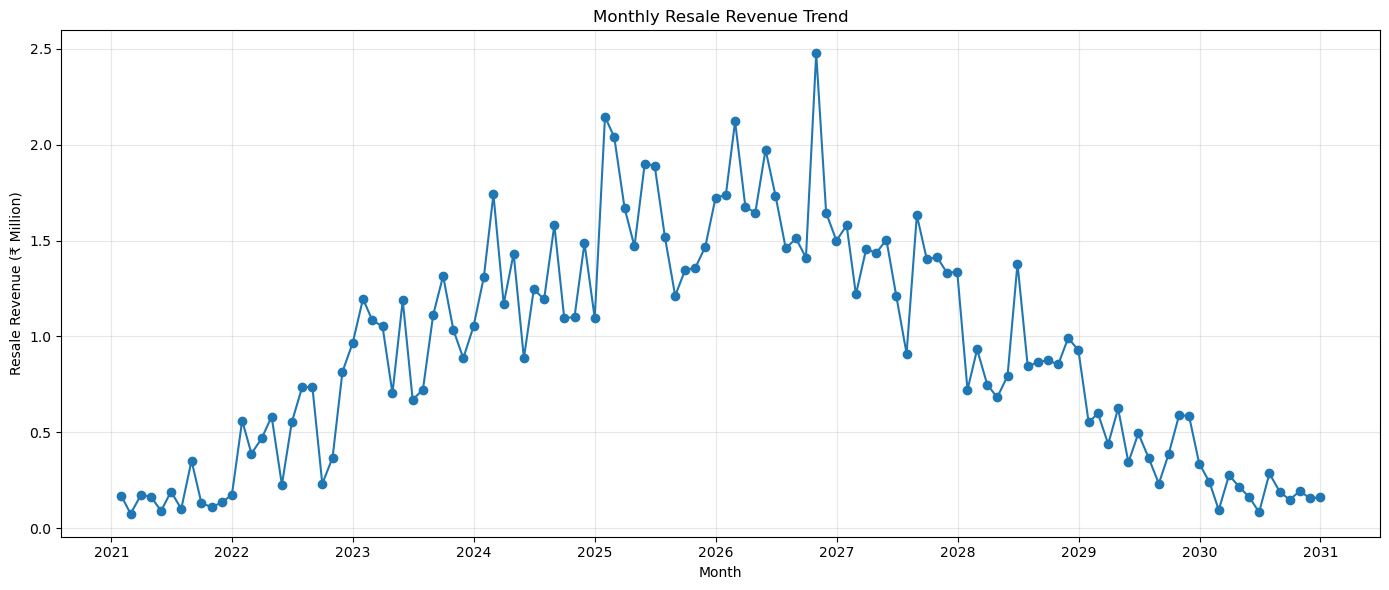

In [13]:
monthly_revenue = (
    df.set_index("Resale_Date")
      .resample("ME")["Resale_Price_INR"]
      .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values / 1_000_000,
    marker="o"
)

plt.title("Monthly Resale Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Resale Revenue (₹ Million)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Top 5 cities by Transactions**

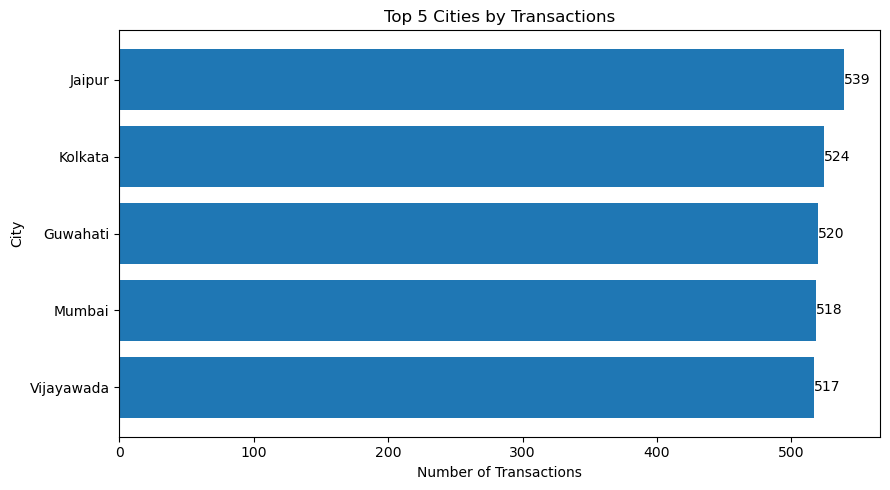

In [14]:
top_cities = (
    df["City"]
    .value_counts()
    .head(5)
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    top_cities.index,
    top_cities.values
)

plt.title("Top 5 Cities by Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("City")

for bar, value in zip(bars, top_cities.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

### **CO₂ savings by Product Category**

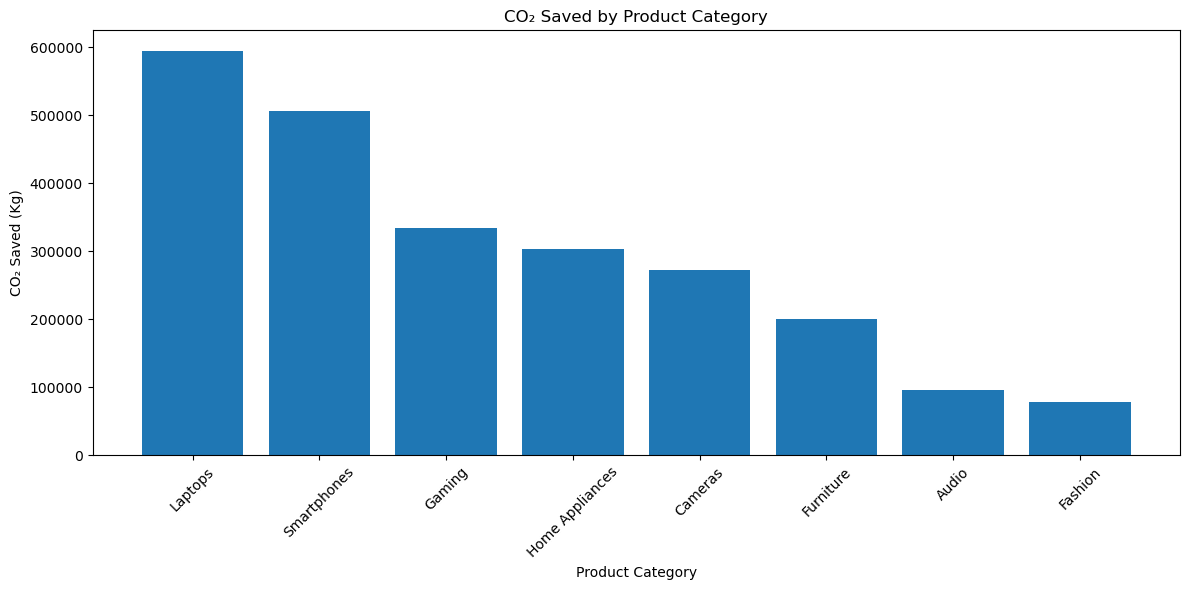

In [15]:
co2_category = (
    df.groupby("Product_Category")["CO2_Saved_Kg"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    co2_category.index,
    co2_category.values
)

plt.title("CO₂ Saved by Product Category")
plt.xlabel("Product Category")
plt.ylabel("CO₂ Saved (Kg)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Customer Rating Distribution**

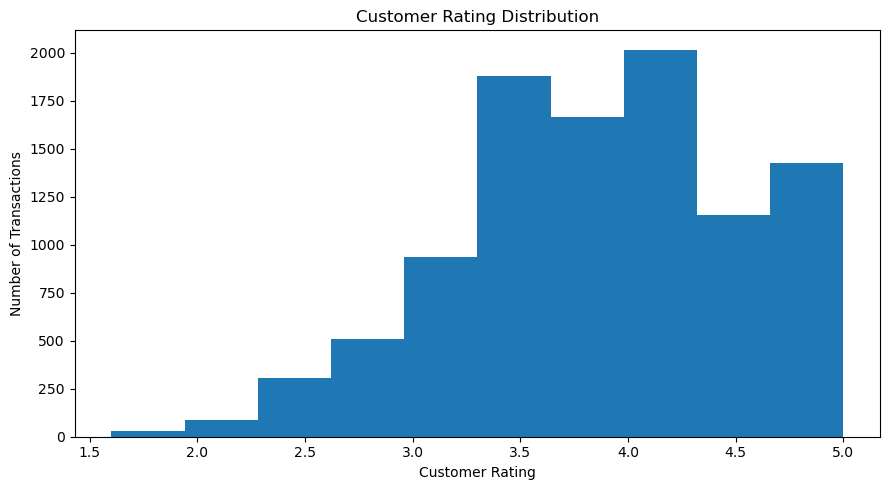

In [16]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["Customer_Rating"],
    bins=10
)

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### **Original Price vs Resale Price**

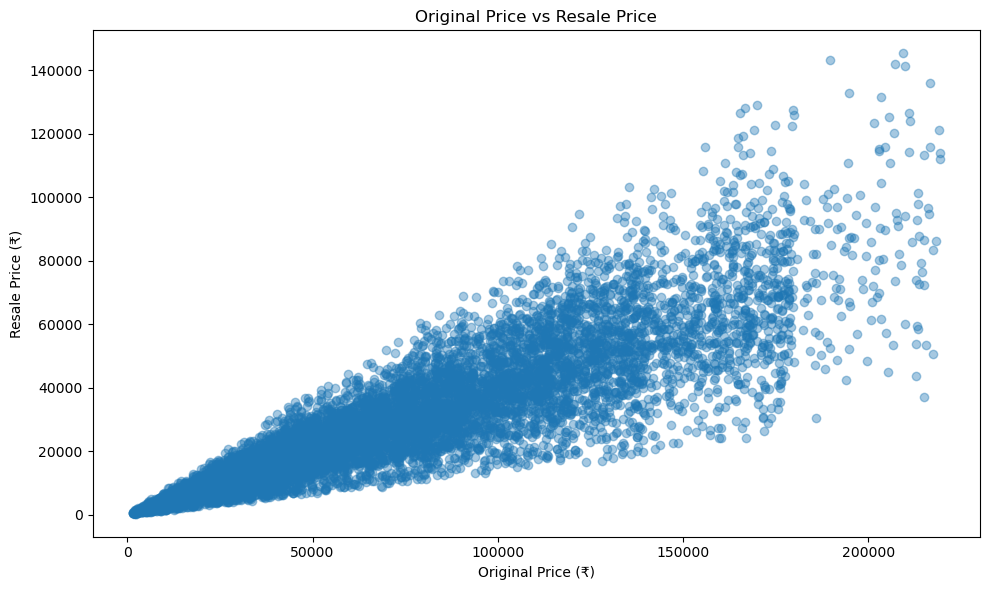

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Original_Price_INR"],
    df["Resale_Price_INR"],
    alpha=0.4
)

plt.title("Original Price vs Resale Price")
plt.xlabel("Original Price (₹)")
plt.ylabel("Resale Price (₹)")

plt.tight_layout()
plt.show()

### **Correlation Analysis**

In [18]:
numeric_columns = [
    "Original_Price_INR",
    "Current_Market_Value_INR",
    "Resale_Price_INR",
    "Ownership_Cycle",
    "Refurbishment_Cost_INR",
    "Repair_Count",
    "Product_Age_Months",
    "Usage_Hours",
    "Material_Recovered_Kg",
    "CO2_Saved_Kg",
    "Waste_Diverted_Kg",
    "Circularity_Score",
    "Customer_Rating"
]

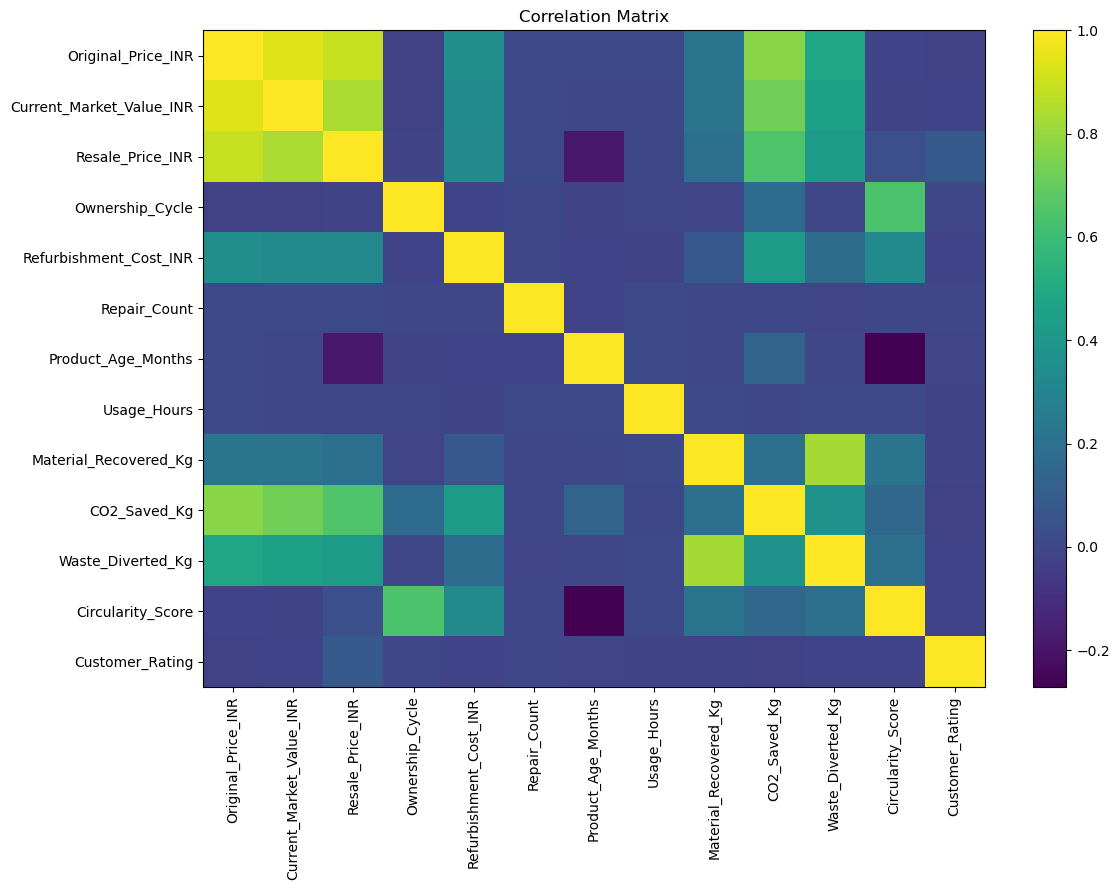

In [19]:
correlation = df[numeric_columns].corr()

plt.figure(figsize=(12, 9))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [21]:
summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Total Original Value",
        "Total Resale Revenue",
        "Average Resale Price",
        "Average Circularity Score",
        "Average Customer Rating",
        "Refurbished Products",
        "Returned Products",
        "Recycling Eligible",
        "Recycled Products",
        "Total CO2 Saved (Kg)",
        "Total Waste Diverted (Kg)",
        "Total Material Recovered (Kg)"
    ],

    "Value": [
        f"{df['Transaction_ID'].nunique():,}",
        f"₹{df['Original_Price_INR'].sum():,.2f}",
        f"₹{df['Resale_Price_INR'].sum():,.2f}",
        f"₹{df['Resale_Price_INR'].mean():,.2f}",
        f"{df['Circularity_Score'].mean():.2f}",
        f"{df['Customer_Rating'].mean():.2f}",
        f"{(df['Refurbished'].str.lower() == 'yes').sum():,}",
        f"{(df['Return_Status'].str.lower() == 'returned').sum():,}",
        f"{(df['Recycling_Eligible'].str.lower() == 'yes').sum():,}",
        f"{(df['Recycled'].str.lower() == 'yes').sum():,}",
        f"{df['CO2_Saved_Kg'].sum():,.0f}",
        f"{df['Waste_Diverted_Kg'].sum():,.0f}",
        f"{df['Material_Recovered_Kg'].sum():,.0f}"
    ]
})

display(summary)

,Metric,Value
0,Total Transactions,"10,000"
1,Total Original Value,"₹697,009,100.00"
2,Total Resale Revenue,"₹283,401,820.00"
3,Average Resale Price,"₹28,340.18"
4,Average Circularity Score,60.72
5,Average Customer Rating,3.87
6,Refurbished Products,"3,775"
7,Returned Products,669
8,Recycling Eligible,"8,657"
9,Recycled Products,"1,514"
